# NIFTY50 Alpha#1 — Trade Optimization & Regime-Gated Research

This notebook starts from the validated/oriented Alpha#1 research workflow and asks a more practical question:

> Can we convert Alpha#1 into a better trade-generation rule by using thresholds, regimes, and risk controls?

The goal is **not** to force a profitable strategy. The goal is to learn whether Alpha#1 has a robust pocket of usefulness:

1. Which thresholds reduce bad trades?
2. Which market regimes help or hurt Alpha#1?
3. Can we reduce drawdown without destroying returns?
4. Does optimization survive walk-forward testing?
5. What trade-candidate rule is reasonable for the MFT system?

Notebook role in MFT:

- This is a **research/review notebook**.
- It should write only CSV artifacts to `research/artifacts/alpha001_nifty50_optimization/`.
- It should not mutate DuckDB or project research tables.


## 1. Research discipline

The key mistake to avoid is optimizing on the same data used to judge success.

We therefore separate the workflow into three levels:

| Level | Purpose | Decision |
|---|---|---|
| Diagnostic | Understand raw/oriented Alpha#1 behavior | Is the signal direction usable? |
| Optimization | Search thresholds and gates | Which rule family looks promising? |
| Walk-forward validation | Test chosen rule out of sample | Does it survive outside the fitting window? |

A threshold or regime rule is only interesting if it improves **out-of-sample Sharpe and drawdown**, not merely in-sample backtest results.


## 2. Alpha#1 reminder

The raw Alpha#1 formula is:

```text
Alpha#1 = rank(
    ts_argmax(
        signedpower(
            ((returns < 0) ? stddev(returns, 20) : close),
            2
        ),
        5
    )
) - 0.5
```

Critical interpretation:

- `rank` is **cross-sectional** across the universe on each date.
- The raw formula direction is not guaranteed to be bullish in NIFTY50.
- We use an **oriented signal**: if historical IC is negative, we flip the raw signal so that higher oriented values are treated as more bullish.


In [1]:
from __future__ import annotations

import itertools
import math
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


In [ ]:
# -----------------------------
# User configuration
# -----------------------------

START_DATE = "2018-01-01"
END_DATE = None

DEFAULT_HORIZON = 5
FORWARD_HORIZONS = [1, 3, 5, 10]

# Research artifacts are written here.
ARTIFACT_DIR = Path("research/artifacts/alpha001_nifty50_optimization")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Optimization search space. Keep deliberately small at first.
TOP_N_GRID = [3, 5, 10, 15]
REBALANCE_GRID = [1, 3, 5]        # rebalance every N sessions
MIN_SIGNAL_GRID = [0.00, 0.10, 0.20, 0.30, 0.40]
MAX_HOLDINGS_GRID = [3, 5, 10]
STOP_LOSS_GRID = [None, -0.04, -0.06, -0.08]  # daily portfolio drawdown-from-entry proxy, simple v0
REGIME_FILTER_GRID = [
    "all",
    "nifty_bull_or_sideways",
    "nifty_bull_only",
    "not_high_vol",
    "bull_and_not_high_vol",
]

ROUND_TRIP_COST_BPS = 20.0
ANNUALIZATION = 252
MIN_OBSERVATIONS = 252

# Current NIFTY50-style universe for rapid research.
# For production, replace this with historical index membership snapshots.
NIFTY50_SYMBOLS = [
    "ADANIENT", "ADANIPORTS", "APOLLOHOSP", "ASIANPAINT", "AXISBANK",
    "BAJAJ-AUTO", "BAJFINANCE", "BAJAJFINSV", "BEL", "BHARTIARTL",
    "CIPLA", "COALINDIA", "DRREDDY", "EICHERMOT", "ETERNAL",
    "GRASIM", "HCLTECH", "HDFCBANK", "HDFCLIFE", "HINDALCO",
    "HINDUNILVR", "ICICIBANK", "INDIGO", "INFY", "ITC",
    "JIOFIN", "JSWSTEEL", "KOTAKBANK", "LT", "M&M",
    "MARUTI", "MAXHEALTH", "NESTLEIND", "NTPC", "ONGC",
    "POWERGRID", "RELIANCE", "SBILIFE", "SHRIRAMFIN", "SBIN",
    "SUNPHARMA", "TATACONSUM", "TATAMOTORS", "TATASTEEL", "TCS",
    "TECHM", "TITAN", "TRENT", "ULTRACEMCO", "WIPRO",
]
YF_TICKERS = [f"{s}.NS" for s in NIFTY50_SYMBOLS]
SYMBOL_FROM_YF = dict(zip(YF_TICKERS, NIFTY50_SYMBOLS))


## 3. Data loading

This notebook can run in two ways:

1. **Fresh Yahoo Finance download** using `yfinance`.
2. **Cached CSV inputs**, if you export OHLCV panels from a previous run.

For reliable production research, use the MFT project's canonical data ingestion and dataset snapshot flow. This notebook is for rapid research and learning.


In [3]:
def download_yf_panel(tickers: list[str], start: str, end: str | None = None) -> pd.DataFrame:
    try:
        import yfinance as yf
    except ImportError as exc:
        raise RuntimeError("Install yfinance first: pip install yfinance") from exc

    data = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        group_by="ticker",
        progress=False,
        threads=True,
    )
    if data.empty:
        raise ValueError("No data downloaded. Check internet access and Yahoo Finance tickers.")
    return data


def extract_field(raw_data: pd.DataFrame, field: str) -> pd.DataFrame:
    frames = {}
    for yf_ticker in YF_TICKERS:
        symbol = SYMBOL_FROM_YF[yf_ticker]
        try:
            if isinstance(raw_data.columns, pd.MultiIndex):
                if yf_ticker in raw_data.columns.get_level_values(0):
                    series = raw_data[(yf_ticker, field)]
                else:
                    continue
            else:
                series = raw_data[field]
            frames[symbol] = series.astype(float)
        except Exception:
            continue
    out = pd.DataFrame(frames).sort_index()
    out.index = pd.to_datetime(out.index).tz_localize(None)
    return out

raw_data = download_yf_panel(YF_TICKERS + ["^NSEI"], START_DATE, END_DATE)

open_px = extract_field(raw_data, "Open")
high_px = extract_field(raw_data, "High")
low_px = extract_field(raw_data, "Low")
close_px = extract_field(raw_data, "Close")
adj_close_px = extract_field(raw_data, "Adj Close")
volume = extract_field(raw_data, "Volume")

nifty_raw = download_yf_panel(["^NSEI"], START_DATE, END_DATE)
if isinstance(nifty_raw.columns, pd.MultiIndex):
    nifty_close = nifty_raw[("^NSEI", "Close")].astype(float)
else:
    nifty_close = nifty_raw["Close"].astype(float)
nifty_close.index = pd.to_datetime(nifty_close.index).tz_localize(None)

print("Downloaded symbols:", len(close_px.columns))
display(close_px.tail())


/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/home/wm0395/Investment/mft_project/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future versio

Downloaded symbols: 50


,ADANIENT,ADANIPORTS,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJFINANCE,BAJAJFINSV,BEL,BHARTIARTL,CIPLA,COALINDIA,DRREDDY,EICHERMOT,ETERNAL,GRASIM,HCLTECH,HDFCBANK,HDFCLIFE,HINDALCO,HINDUNILVR,ICICIBANK,INDIGO,INFY,ITC,JIOFIN,JSWSTEEL,KOTAKBANK,LT,M&M,MARUTI,MAXHEALTH,NESTLEIND,NTPC,ONGC,POWERGRID,RELIANCE,SBILIFE,SHRIRAMFIN,SBIN,SUNPHARMA,TATACONSUM,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-12,2405.199951,1688.199951,8022.5,2505.500000,1260.099976,10397.0,904.200012,1744.800049,416.500000,1756.800049,1292.300049,463.049988,1270.000000,7126.0,239.979996,2903.000000,1145.800049,750.450012,601.799988,1041.400024,2262.000000,1240.300049,4201.700195,1140.300049,300.700012,230.470001,1252.300049,376.000000,3856.500000,3176.000000,13172.0,1017.700012,1468.599976,392.700012,294.500000,306.299988,1364.000000,1833.900024,930.450012,974.599976,1845.699951,1253.000000,NaN,212.000000,2300.300049,1392.900024,4055.300049,4050.600098,11516.0,189.570007
2026-05-13,2498.000000,1737.800049,8004.5,2617.600098,1255.699951,10262.0,896.150024,1728.900024,428.250000,1789.199951,1327.599976,462.250000,1265.300049,6971.5,237.820007,2945.600098,1143.199951,749.599976,602.799988,1073.099976,2267.300049,1235.599976,4255.799805,1123.099976,304.450012,231.449997,1274.900024,377.649994,3915.800049,3111.800049,13103.0,1026.099976,1468.900024,390.450012,297.149994,301.500000,1358.800049,1837.500000,920.549988,970.099976,1824.800049,1235.000000,NaN,219.619995,2272.800049,1375.000000,4090.699951,4084.500000,11573.0,187.800003
2026-05-14,2712.899902,1773.400024,8119.0,2622.199951,1254.599976,10451.0,912.150024,1740.199951,428.850006,1883.500000,1436.699951,454.049988,1303.599976,7034.0,245.820007,2938.699951,1124.000000,769.549988,612.549988,1103.300049,2248.699951,1246.000000,4280.500000,1095.000000,307.200012,234.130005,1296.900024,383.200012,3940.399902,3173.899902,13075.0,1049.550049,1459.599976,396.299988,300.899994,301.750000,1361.800049,1866.699951,935.099976,979.900024,1863.199951,1228.300049,NaN,221.130005,2246.000000,1343.400024,4135.200195,4132.399902,11692.0,188.300003
2026-05-15,2716.000000,1795.099976,8082.5,2605.600098,1244.800049,10377.5,910.450012,1728.099976,423.649994,1905.400024,1432.099976,462.200012,1336.699951,7014.5,241.179993,2933.800049,1132.599976,767.500000,608.700012,1067.500000,2272.199951,1244.500000,4314.899902,1119.000000,309.450012,233.059998,1278.800049,387.049988,3909.000000,3123.100098,13221.0,1050.099976,1430.500000,395.250000,299.350006,305.850006,1336.400024,1864.500000,937.900024,963.200012,1878.199951,1234.000000,NaN,216.839996,2264.000000,1370.500000,4169.100098,4101.299805,11487.0,190.000000
2026-05-18,2689.800049,1787.699951,8020.5,2614.000000,1237.900024,10198.5,921.099976,1753.099976,426.600006,1938.099976,1426.199951,462.100006,1331.199951,6913.0,241.399994,2943.800049,1146.599976,768.650024,604.950012,1053.099976,2254.199951,1251.099976,4275.700195,1142.500000,310.149994,232.630005,1292.800049,391.799988,3917.800049,3083.699951,13016.0,1058.550049,1431.699951,388.299988,297.200012,296.549988,1335.900024,1860.400024,933.700012,939.400024,1905.800049,1231.000000,NaN,209.710007,2283.199951,1430.000000,4169.700195,4032.300049,11561.0,192.169998


## 4. Data validation checkpoint

Before optimizing thresholds, reject bad data. Thresholding can easily exploit data errors.

We check:

- missingness by symbol
- OHLC consistency
- zero/negative price
- negative volume
- suspicious adjusted-return outliers
- universe size after filtering


In [4]:
def validate_ohlcv_panel(open_px, high_px, low_px, close_px, volume, adj_close_px=None) -> tuple[pd.DataFrame, pd.DataFrame]:
    symbols = sorted(set(open_px.columns) & set(high_px.columns) & set(low_px.columns) & set(close_px.columns) & set(volume.columns))
    rows = []
    examples = []
    for s in symbols:
        o, h, l, c, v = open_px[s], high_px[s], low_px[s], close_px[s], volume[s]
        common = pd.concat({"open": o, "high": h, "low": l, "close": c, "volume": v}, axis=1)
        missing_ratio = common.isna().mean().mean()
        invalid_ohlc = ((common["high"] < common[["open", "close"]].max(axis=1)) | (common["low"] > common[["open", "close"]].min(axis=1)) | (common["low"] > common["high"])).sum()
        nonpositive_price = (common[["open", "high", "low", "close"]] <= 0).sum().sum()
        negative_volume = (common["volume"] < 0).sum()
        suspicious_returns = 0
        if adj_close_px is not None and s in adj_close_px:
            r = adj_close_px[s].pct_change()
            suspicious_returns = (r.abs() > 0.25).sum()
            bad_dates = r[r.abs() > 0.25].index[:5]
            for d in bad_dates:
                examples.append({"symbol": s, "date": d, "issue": "abs_adj_return_gt_25pct", "value": r.loc[d]})
        rows.append({
            "symbol": s,
            "rows": len(common),
            "missing_ratio": missing_ratio,
            "invalid_ohlc_rows": int(invalid_ohlc),
            "nonpositive_price_cells": int(nonpositive_price),
            "negative_volume_rows": int(negative_volume),
            "suspicious_adj_return_rows": int(suspicious_returns),
        })
    return pd.DataFrame(rows).sort_values(["invalid_ohlc_rows", "missing_ratio"], ascending=[False, False]), pd.DataFrame(examples)

validation_report, validation_examples = validate_ohlcv_panel(open_px, high_px, low_px, close_px, volume, adj_close_px)
display(validation_report.head(20))
if not validation_examples.empty:
    display(validation_examples.head(20))

# Conservative cleaning for this notebook.
MAX_MISSING_RATIO = 0.20
bad_symbols = validation_report.query(
    "missing_ratio > @MAX_MISSING_RATIO or invalid_ohlc_rows > 0 or nonpositive_price_cells > 0 or negative_volume_rows > 0"
)["symbol"].tolist()

print("Bad symbols removed:", bad_symbols)
valid_symbols = [s for s in close_px.columns if s not in set(bad_symbols)]

open_px = open_px[valid_symbols]
high_px = high_px[valid_symbols]
low_px = low_px[valid_symbols]
close_px = close_px[valid_symbols]
adj_close_px = adj_close_px[valid_symbols]
volume = volume[valid_symbols]

# Use adjusted close for return calculations, but raw close for formula component that explicitly says close.
ret = adj_close_px.pct_change()

print("Valid universe size:", len(valid_symbols))


,symbol,rows,missing_ratio,invalid_ohlc_rows,nonpositive_price_cells,negative_volume_rows,suspicious_adj_return_rows
42,TATAMOTORS,2068,1.000000,0,0,0,0
25,JIOFIN,2068,0.676015,0,0,0,0
14,ETERNAL,2068,0.435203,0,0,0,0
31,MAXHEALTH,2068,0.313346,0,0,0,0
22,INDIGO,2068,0.000484,0,0,0,0
0,ADANIENT,2068,0.000000,0,0,0,3
1,ADANIPORTS,2068,0.000000,0,0,0,0
2,APOLLOHOSP,2068,0.000000,0,0,0,0
3,ASIANPAINT,2068,0.000000,0,0,0,0
4,AXISBANK,2068,0.000000,0,0,0,1


,symbol,date,issue,value
0,ADANIENT,2019-05-20,abs_adj_return_gt_25pct,0.273680
1,ADANIENT,2023-02-01,abs_adj_return_gt_25pct,-0.281970
2,ADANIENT,2023-02-02,abs_adj_return_gt_25pct,-0.266982
3,AXISBANK,2020-03-23,abs_adj_return_gt_25pct,-0.279108
4,BAJAJFINSV,2020-03-23,abs_adj_return_gt_25pct,-0.258621


Bad symbols removed: ['TATAMOTORS', 'JIOFIN', 'ETERNAL', 'MAXHEALTH']
Valid universe size: 46


## 5. Alpha#1 operator implementation

This cell computes both:

- `raw_alpha001`: literal paper-style signal
- `oriented_alpha001`: signal flipped if the historical rank IC says raw direction is bearish

The raw signal is the research object. The oriented signal is the trade-construction object.


In [5]:
def cross_sectional_rank(df: pd.DataFrame, pct: bool = True) -> pd.DataFrame:
    return df.rank(axis=1, pct=pct)


def ts_argmax_recent_position(df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Return 1..window position of rolling maximum, where larger means more recent max.

    Using larger=more recent is intuitive for this research. If you want literal numpy argmax
    position from oldest to newest, change this deliberately and rerun the notebook.
    """
    def _pos(values: np.ndarray) -> float:
        if np.isnan(values).all():
            return np.nan
        # np.nanargmax gives 0 for oldest, window-1 for newest. Add 1 for 1..window.
        return float(np.nanargmax(values) + 1)
    return df.rolling(window).apply(_pos, raw=True)


def compute_alpha001(close_px: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    vol20 = returns.rolling(20).std()
    condition_value = close_px.where(returns >= 0, vol20)
    signed_power = np.sign(condition_value) * (np.abs(condition_value) ** 2)
    argmax5 = ts_argmax_recent_position(signed_power, 5)
    return cross_sectional_rank(argmax5, pct=True) - 0.5


def forward_returns(price: pd.DataFrame, horizon: int) -> pd.DataFrame:
    return price.shift(-horizon) / price - 1.0

raw_alpha001 = compute_alpha001(close_px, ret)
fwd_returns = {h: forward_returns(adj_close_px, h) for h in FORWARD_HORIZONS}

def daily_rank_ic(alpha: pd.DataFrame, fwd: pd.DataFrame, method: str = "spearman") -> pd.Series:
    values = []
    for dt in alpha.index.intersection(fwd.index):
        a = alpha.loc[dt]
        r = fwd.loc[dt]
        valid = a.notna() & r.notna()
        if valid.sum() < 10:
            values.append((dt, np.nan))
        else:
            values.append((dt, a[valid].corr(r[valid], method=method)))
    return pd.Series(dict(values)).sort_index()

raw_ic_by_horizon = {h: daily_rank_ic(raw_alpha001, fwd_returns[h]) for h in FORWARD_HORIZONS}
ic_summary = pd.DataFrame([
    {
        "horizon": h,
        "mean_rank_ic": s.mean(),
        "median_rank_ic": s.median(),
        "ic_vol": s.std(),
        "icir": s.mean() / s.std() if s.std() and not np.isnan(s.std()) else np.nan,
        "positive_ic_rate": (s > 0).mean(),
        "observations": s.notna().sum(),
    }
    for h, s in raw_ic_by_horizon.items()
]).set_index("horizon")

display(ic_summary)

SIGNAL_DIRECTION = 1 if ic_summary.loc[DEFAULT_HORIZON, "mean_rank_ic"] >= 0 else -1
ORIENTATION_LABEL = "raw" if SIGNAL_DIRECTION == 1 else "inverted"
oriented_alpha001 = SIGNAL_DIRECTION * raw_alpha001
print("Signal orientation:", ORIENTATION_LABEL, "SIGNAL_DIRECTION=", SIGNAL_DIRECTION)


,mean_rank_ic,median_rank_ic,ic_vol,icir,positive_ic_rate,observations
horizon,,,,,,
1,-0.021847,-0.024385,0.176535,-0.123754,0.436170,2043
3,-0.020194,-0.021794,0.172916,-0.116782,0.444391,2043
5,-0.016873,-0.016494,0.176409,-0.095646,0.461799,2041
10,-0.012733,-0.006209,0.178686,-0.071259,0.480658,2036


Signal orientation: inverted SIGNAL_DIRECTION= -1


## 6. Baseline strategy

Before optimizing, define a transparent baseline:

- each rebalance day, select top `N` oriented Alpha#1 stocks
- equal weight selected names
- hold until next rebalance
- subtract transaction costs based on portfolio turnover

This gives us a benchmark to beat.


In [6]:
def make_regime_frame(nifty_close: pd.Series) -> pd.DataFrame:
    n = nifty_close.dropna().copy()
    sma50 = n.rolling(50).mean()
    sma200 = n.rolling(200).mean()
    ret_n = n.pct_change()
    vol20 = ret_n.rolling(20).std() * math.sqrt(252)
    vol_q_low = vol20.rolling(252, min_periods=100).quantile(0.33)
    vol_q_high = vol20.rolling(252, min_periods=100).quantile(0.67)

    trend = pd.Series("sideways", index=n.index, dtype="object")
    trend[(n > sma50) & (sma50 > sma200)] = "bull"
    trend[(n < sma50) & (sma50 < sma200)] = "bear"

    vol_regime = pd.Series("medium_vol", index=n.index, dtype="object")
    vol_regime[vol20 <= vol_q_low] = "low_vol"
    vol_regime[vol20 >= vol_q_high] = "high_vol"

    return pd.DataFrame({
        "nifty_close": n,
        "nifty_ret": ret_n,
        "nifty_sma50": sma50,
        "nifty_sma200": sma200,
        "nifty_vol20_ann": vol20,
        "trend_regime": trend,
        "vol_regime": vol_regime,
    })

regimes = make_regime_frame(nifty_close)
display(regimes.tail())


def allowed_by_regime(regime_row: pd.Series, regime_filter: str) -> bool:
    if regime_filter == "all":
        return True
    if regime_filter == "nifty_bull_or_sideways":
        return regime_row.get("trend_regime") in {"bull", "sideways"}
    if regime_filter == "nifty_bull_only":
        return regime_row.get("trend_regime") == "bull"
    if regime_filter == "not_high_vol":
        return regime_row.get("vol_regime") != "high_vol"
    if regime_filter == "bull_and_not_high_vol":
        return regime_row.get("trend_regime") == "bull" and regime_row.get("vol_regime") != "high_vol"
    raise ValueError(f"Unknown regime_filter: {regime_filter}")


,nifty_close,nifty_ret,nifty_sma50,nifty_sma200,nifty_vol20_ann,trend_regime,vol_regime
Date,,,,,,,
2026-05-12,23379.550781,-0.018320,23912.513086,25057.102852,0.148926,bear,high_vol
2026-05-13,23412.599609,0.001414,23872.272070,25048.608604,0.146673,bear,high_vol
2026-05-14,23689.599609,0.011831,23836.414062,25042.214600,0.140460,bear,high_vol
2026-05-15,23643.500000,-0.001946,23799.353047,25034.978604,0.140489,bear,high_vol
2026-05-18,23649.949219,0.000273,23768.779023,25027.923848,0.137736,bear,high_vol


In [7]:
@dataclass(frozen=True)
class StrategyParams:
    top_n: int
    min_signal: float
    rebalance_every: int
    max_holdings: int
    regime_filter: str
    stop_loss: float | None
    cost_bps: float = ROUND_TRIP_COST_BPS


def build_target_weights(alpha: pd.DataFrame, regimes: pd.DataFrame, params: StrategyParams) -> pd.DataFrame:
    weights = pd.DataFrame(0.0, index=alpha.index, columns=alpha.columns)
    dates = list(alpha.index)
    for i, dt in enumerate(dates):
        if i % params.rebalance_every != 0:
            continue
        if dt not in regimes.index or not allowed_by_regime(regimes.loc[dt], params.regime_filter):
            continue
        scores = alpha.loc[dt].dropna().sort_values(ascending=False)
        scores = scores[scores >= params.min_signal]
        selected = scores.head(min(params.top_n, params.max_holdings)).index.tolist()
        if selected:
            weights.loc[dt, selected] = 1.0 / len(selected)
    # Hold weights between rebalance dates. If rebalance creates zeros, go to cash.
    weights = weights.replace(0.0, np.nan).ffill().fillna(0.0)
    # But preserve deliberate cash dates: if a rebalance date has all-zero target, subsequent period should be cash.
    rebalance_mask = pd.Series(False, index=alpha.index)
    rebalance_mask.iloc[::params.rebalance_every] = True
    for dt in alpha.index[rebalance_mask]:
        if weights.loc[dt].sum() == 0:
            # from this date until next rebalance, force cash; loop is simple and explicit
            start = alpha.index.get_loc(dt)
            end = min(start + params.rebalance_every, len(alpha.index))
            weights.iloc[start:end] = 0.0
    return weights


def apply_simple_stop_loss(portfolio_returns: pd.Series, weights: pd.DataFrame, stop_loss: float | None, rebalance_every: int) -> tuple[pd.Series, pd.DataFrame]:
    if stop_loss is None:
        return portfolio_returns, weights
    adjusted = portfolio_returns.copy()
    adjusted_weights = weights.copy()
    dates = list(portfolio_returns.index)
    for start in range(0, len(dates), rebalance_every):
        end = min(start + rebalance_every, len(dates))
        block_dates = dates[start:end]
        cumulative = 0.0
        stopped = False
        for dt in block_dates:
            if stopped:
                adjusted.loc[dt] = 0.0
                adjusted_weights.loc[dt] = 0.0
                continue
            cumulative = (1 + cumulative) * (1 + adjusted.loc[dt]) - 1
            if cumulative <= stop_loss:
                stopped = True
    return adjusted, adjusted_weights


def backtest_long_only(alpha: pd.DataFrame, next_day_returns: pd.DataFrame, regimes: pd.DataFrame, params: StrategyParams) -> dict:
    common_index = alpha.index.intersection(next_day_returns.index).intersection(regimes.index)
    alpha = alpha.loc[common_index]
    rets = next_day_returns.loc[common_index]
    regimes = regimes.loc[common_index]

    weights = build_target_weights(alpha, regimes, params)
    # Signal at close today, earn next-day close-to-close return.
    gross_returns = (weights.shift(1).fillna(0.0) * rets).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    costs = turnover * (params.cost_bps / 10000.0)
    net_returns = gross_returns - costs
    net_returns, stopped_weights = apply_simple_stop_loss(net_returns, weights, params.stop_loss, params.rebalance_every)
    metrics = compute_metrics(net_returns, stopped_weights, turnover)
    return {"returns": net_returns, "weights": stopped_weights, "turnover": turnover, "metrics": metrics}


def compute_metrics(returns: pd.Series, weights: pd.DataFrame, turnover: pd.Series) -> dict:
    r = returns.dropna()
    if len(r) == 0:
        return {k: np.nan for k in ["total_return", "ann_return", "ann_vol", "sharpe", "max_drawdown", "calmar", "hit_rate", "avg_turnover", "exposure", "days"]}
    equity = (1 + r).cumprod()
    peak = equity.cummax()
    dd = equity / peak - 1
    ann_return = equity.iloc[-1] ** (ANNUALIZATION / len(r)) - 1 if len(r) > 0 else np.nan
    ann_vol = r.std() * math.sqrt(ANNUALIZATION)
    sharpe = ann_return / ann_vol if ann_vol and not np.isnan(ann_vol) else np.nan
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan
    exposure = (weights.abs().sum(axis=1) > 0).mean()
    return {
        "total_return": equity.iloc[-1] - 1,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
        "calmar": calmar,
        "hit_rate": (r > 0).mean(),
        "avg_daily_return": r.mean(),
        "avg_turnover": turnover.reindex(r.index).mean(),
        "exposure": exposure,
        "days": len(r),
    }

next_day_returns = adj_close_px.pct_change().shift(-1)

baseline_params = StrategyParams(top_n=10, min_signal=0.0, rebalance_every=1, max_holdings=10, regime_filter="all", stop_loss=None)
baseline = backtest_long_only(oriented_alpha001, next_day_returns, regimes, baseline_params)
pd.Series(baseline["metrics"]).to_frame("baseline")


,baseline
total_return,107.470549
ann_return,0.773121
ann_vol,0.786397
sharpe,0.983119
max_drawdown,-0.932323
calmar,0.829242
hit_rate,0.562076
avg_daily_return,0.003592
avg_turnover,0.010991
exposure,0.990786


## 7. Threshold and regime optimization

We now search a small parameter grid:

- `top_n`: how many stocks to consider
- `min_signal`: only trade when oriented Alpha#1 is strong enough
- `rebalance_every`: daily / 3-day / 5-day refresh
- `max_holdings`: cap concentration
- `regime_filter`: only trade in selected market regimes
- `stop_loss`: simple portfolio stop within each rebalance block

Interpretation rule:

> A parameter set is not good because it has the highest Sharpe. It is good only if it improves Sharpe, reduces max drawdown, keeps enough observations, and survives walk-forward validation.


In [8]:
def params_grid() -> list[StrategyParams]:
    out = []
    for top_n, min_signal, rebalance_every, max_holdings, regime_filter, stop_loss in itertools.product(
        TOP_N_GRID, MIN_SIGNAL_GRID, REBALANCE_GRID, MAX_HOLDINGS_GRID, REGIME_FILTER_GRID, STOP_LOSS_GRID
    ):
        if max_holdings > top_n:
            continue
        out.append(StrategyParams(
            top_n=top_n,
            min_signal=min_signal,
            rebalance_every=rebalance_every,
            max_holdings=max_holdings,
            regime_filter=regime_filter,
            stop_loss=stop_loss,
        ))
    return out


def evaluate_params(alpha, returns, regimes, grid: list[StrategyParams]) -> pd.DataFrame:
    rows = []
    for p in grid:
        bt = backtest_long_only(alpha, returns, regimes, p)
        row = {
            "top_n": p.top_n,
            "min_signal": p.min_signal,
            "rebalance_every": p.rebalance_every,
            "max_holdings": p.max_holdings,
            "regime_filter": p.regime_filter,
            "stop_loss": p.stop_loss,
            **bt["metrics"],
        }
        rows.append(row)
    return pd.DataFrame(rows)

search_results = evaluate_params(oriented_alpha001, next_day_returns, regimes, params_grid())
search_results["score"] = (
    search_results["sharpe"].fillna(-999)
    + 0.5 * search_results["calmar"].replace([np.inf, -np.inf], np.nan).fillna(-999)
    - 2.0 * search_results["max_drawdown"].abs().fillna(1)
    - 0.25 * search_results["avg_turnover"].fillna(1)
)

filtered_results = search_results.query("days >= @MIN_OBSERVATIONS and exposure >= 0.05").copy()
leaderboard = filtered_results.sort_values(["score", "sharpe", "max_drawdown"], ascending=[False, False, False]).head(25)
display(leaderboard)

search_results.to_csv(ARTIFACT_DIR / "alpha001_threshold_regime_grid_results.csv", index=False)
leaderboard.to_csv(ARTIFACT_DIR / "alpha001_threshold_regime_leaderboard.csv", index=False)


,top_n,min_signal,rebalance_every,max_holdings,regime_filter,stop_loss,total_return,ann_return,ann_vol,sharpe,max_drawdown,calmar,hit_rate,avg_daily_return,avg_turnover,exposure,days,score
1434,10,0.2,5,10,not_high_vol,-0.06,67.096264,0.675053,0.680596,0.991856,-0.819384,0.823855,0.476722,0.003051,0.012906,0.835597,2062,-0.238211
2334,15,0.2,5,10,not_high_vol,-0.06,67.096264,0.675053,0.680596,0.991856,-0.819384,0.823855,0.476722,0.003051,0.012906,0.835597,2062,-0.238211
1426,10,0.2,5,10,nifty_bull_or_sideways,-0.06,60.726759,0.655070,0.678296,0.965758,-0.812095,0.806642,0.472842,0.002988,0.018152,0.832687,2062,-0.259648
2326,15,0.2,5,10,nifty_bull_or_sideways,-0.06,60.726759,0.655070,0.678296,0.965758,-0.812095,0.806642,0.472842,0.002988,0.018152,0.832687,2062,-0.259648
1250,10,0.1,5,10,nifty_bull_only,-0.06,42.704492,0.586686,0.624403,0.939596,-0.791662,0.741081,0.424345,0.002675,0.003589,0.733754,2062,-0.274086
2150,15,0.1,5,10,nifty_bull_only,-0.06,42.704492,0.586686,0.624403,0.939596,-0.791662,0.741081,0.424345,0.002675,0.003589,0.733754,2062,-0.274086
1422,10,0.2,5,10,all,-0.06,57.262341,0.643428,0.680919,0.944940,-0.812280,0.792125,0.472842,0.002968,0.021477,0.831717,2062,-0.288926
2322,15,0.2,5,10,all,-0.06,57.262341,0.643428,0.680919,0.944940,-0.812280,0.792125,0.472842,0.002968,0.021477,0.831717,2062,-0.288926
1070,10,0.0,5,10,nifty_bull_only,-0.06,39.566409,0.572303,0.624053,0.917074,-0.790545,0.723935,0.424345,0.002638,0.002910,0.734239,2062,-0.302775
1970,15,0.0,5,10,nifty_bull_only,-0.06,39.566409,0.572303,0.624053,0.917074,-0.790545,0.723935,0.424345,0.002638,0.002910,0.734239,2062,-0.302775


## 8. Visual diagnostics for the best in-sample candidate

This section visualizes the current best candidate.

Do **not** promote it yet. This is still in-sample.


StrategyParams(top_n=10, min_signal=0.2, rebalance_every=5, max_holdings=10, regime_filter='not_high_vol', stop_loss=np.float64(-0.06), cost_bps=20.0)


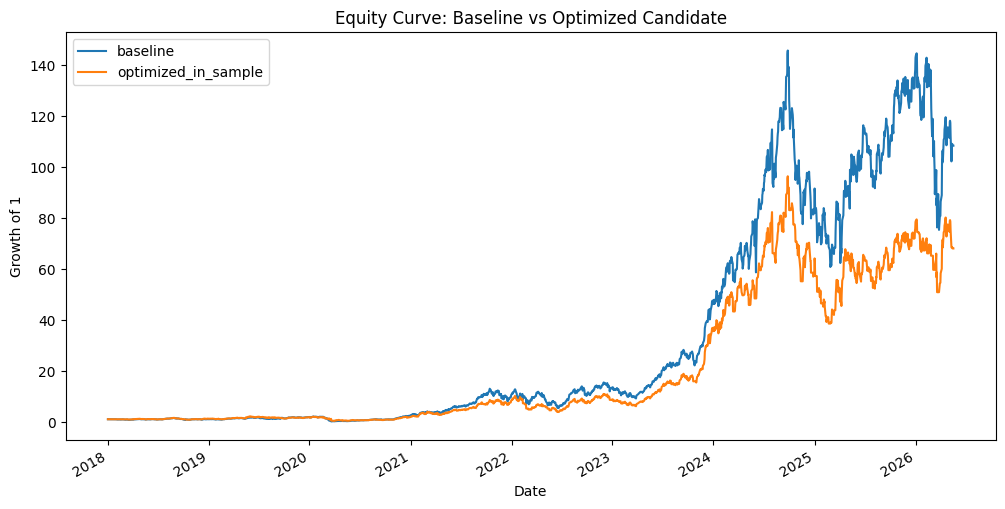

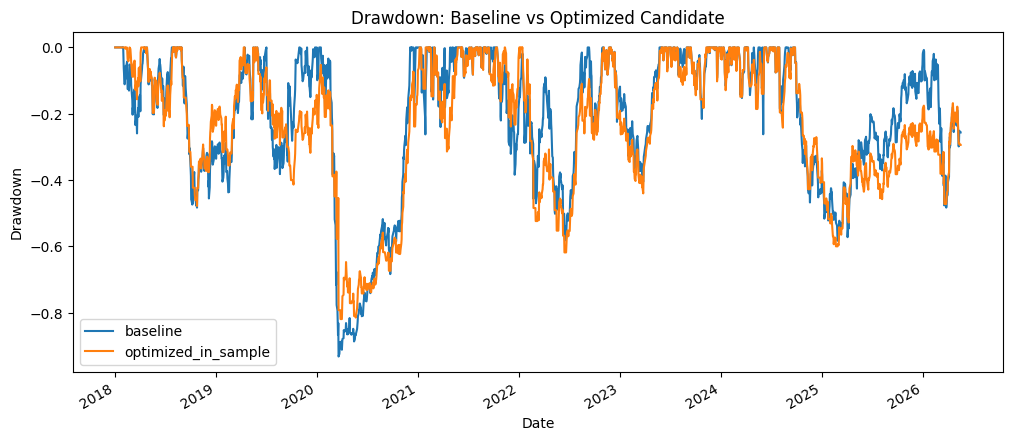

,baseline,optimized_in_sample
total_return,107.470549,67.096264
ann_return,0.773121,0.675053
ann_vol,0.786397,0.680596
sharpe,0.983119,0.991856
max_drawdown,-0.932323,-0.819384
calmar,0.829242,0.823855
hit_rate,0.562076,0.476722
avg_daily_return,0.003592,0.003051
avg_turnover,0.010991,0.012906
exposure,0.990786,0.835597


In [9]:
def params_from_row(row: pd.Series) -> StrategyParams:
    stop_loss = row["stop_loss"]
    if pd.isna(stop_loss):
        stop_loss = None
    return StrategyParams(
        top_n=int(row["top_n"]),
        min_signal=float(row["min_signal"]),
        rebalance_every=int(row["rebalance_every"]),
        max_holdings=int(row["max_holdings"]),
        regime_filter=str(row["regime_filter"]),
        stop_loss=stop_loss,
    )

best_params = params_from_row(leaderboard.iloc[0])
print(best_params)
best_bt = backtest_long_only(oriented_alpha001, next_day_returns, regimes, best_params)
best_returns = best_bt["returns"]
base_returns = baseline["returns"].reindex(best_returns.index).fillna(0.0)

comparison = pd.DataFrame({
    "baseline": (1 + base_returns).cumprod(),
    "optimized_in_sample": (1 + best_returns).cumprod(),
})
comparison.plot(figsize=(12, 6), title="Equity Curve: Baseline vs Optimized Candidate")
plt.ylabel("Growth of 1")
plt.show()

dd = comparison / comparison.cummax() - 1
dd.plot(figsize=(12, 5), title="Drawdown: Baseline vs Optimized Candidate")
plt.ylabel("Drawdown")
plt.show()

pd.DataFrame({
    "baseline": baseline["metrics"],
    "optimized_in_sample": best_bt["metrics"],
})


## 9. Regime attribution

A regime-gated strategy should improve because it avoids bad environments, not because of random curve fitting.

This table asks:

- Which regimes contribute returns?
- Which regimes cause drawdowns?
- Is the selected filter logically consistent with observed behavior?


In [10]:
def regime_attribution(returns: pd.Series, regimes: pd.DataFrame) -> pd.DataFrame:
    df = pd.concat([returns.rename("strategy_return"), regimes[["trend_regime", "vol_regime"]]], axis=1).dropna()
    rows = []
    for group_col in ["trend_regime", "vol_regime"]:
        for name, g in df.groupby(group_col):
            r = g["strategy_return"]
            eq = (1 + r).cumprod()
            dd = eq / eq.cummax() - 1
            ann_ret = eq.iloc[-1] ** (ANNUALIZATION / len(r)) - 1 if len(r) else np.nan
            ann_vol = r.std() * math.sqrt(ANNUALIZATION)
            rows.append({
                "regime_type": group_col,
                "regime": name,
                "days": len(r),
                "ann_return": ann_ret,
                "ann_vol": ann_vol,
                "sharpe": ann_ret / ann_vol if ann_vol and not np.isnan(ann_vol) else np.nan,
                "max_drawdown": dd.min(),
                "hit_rate": (r > 0).mean(),
                "avg_daily_return": r.mean(),
            })
    return pd.DataFrame(rows).sort_values(["regime_type", "sharpe"], ascending=[True, False])

regime_report = regime_attribution(best_returns, regimes)
display(regime_report)
regime_report.to_csv(ARTIFACT_DIR / "alpha001_optimized_regime_attribution.csv", index=False)


,regime_type,regime,days,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,avg_daily_return
1,trend_regime,bull,908,1.370672,0.554982,2.469760,-0.412163,0.544053,0.004050
2,trend_regime,sideways,955,0.402595,0.642379,0.626725,-0.647005,0.429319,0.002189
0,trend_regime,bear,199,-0.195092,1.191790,-0.163696,-0.669945,0.396985,0.002634
4,vol_regime,low_vol,686,1.265731,0.522283,2.423457,-0.439389,0.537901,0.003797
5,vol_regime,medium_vol,717,0.715651,0.589937,1.213097,-0.521700,0.461646,0.002837
3,vol_regime,high_vol,659,0.191677,0.887676,0.215932,-0.806095,0.429439,0.002508


## 10. Walk-forward validation

This is the most important section.

Process:

1. Use a training window to pick parameters.
2. Apply those parameters to the next test window.
3. Roll forward.
4. Combine all out-of-sample test returns.

This prevents us from simply choosing the best historical hindsight rule.


In [11]:
def rolling_windows(index: pd.Index, train_days: int = 504, test_days: int = 126, step_days: int = 126):
    idx = pd.Index(index).sort_values()
    start = 0
    while start + train_days + test_days <= len(idx):
        train_idx = idx[start:start+train_days]
        test_idx = idx[start+train_days:start+train_days+test_days]
        yield train_idx, test_idx
        start += step_days


def walk_forward_optimize(alpha, returns, regimes, grid, train_days=504, test_days=126, step_days=126) -> tuple[pd.DataFrame, pd.Series]:
    wf_rows = []
    oos_returns = []
    common = alpha.index.intersection(returns.index).intersection(regimes.index)
    for fold, (train_idx, test_idx) in enumerate(rolling_windows(common, train_days, test_days, step_days), start=1):
        train_results = evaluate_params(alpha.loc[train_idx], returns.loc[train_idx], regimes.loc[train_idx], grid)
        train_results["score"] = (
            train_results["sharpe"].fillna(-999)
            + 0.5 * train_results["calmar"].replace([np.inf, -np.inf], np.nan).fillna(-999)
            - 2.0 * train_results["max_drawdown"].abs().fillna(1)
            - 0.25 * train_results["avg_turnover"].fillna(1)
        )
        train_results = train_results.query("days >= 126 and exposure >= 0.05")
        if train_results.empty:
            continue
        chosen = train_results.sort_values(["score", "sharpe"], ascending=[False, False]).iloc[0]
        p = params_from_row(chosen)
        test_bt = backtest_long_only(alpha.loc[test_idx], returns.loc[test_idx], regimes.loc[test_idx], p)
        test_r = test_bt["returns"]
        oos_returns.append(test_r)
        wf_rows.append({
            "fold": fold,
            "train_start": train_idx[0],
            "train_end": train_idx[-1],
            "test_start": test_idx[0],
            "test_end": test_idx[-1],
            "chosen_top_n": p.top_n,
            "chosen_min_signal": p.min_signal,
            "chosen_rebalance_every": p.rebalance_every,
            "chosen_max_holdings": p.max_holdings,
            "chosen_regime_filter": p.regime_filter,
            "chosen_stop_loss": p.stop_loss,
            **{f"test_{k}": v for k, v in test_bt["metrics"].items()},
        })
    combined = pd.concat(oos_returns).sort_index() if oos_returns else pd.Series(dtype=float)
    return pd.DataFrame(wf_rows), combined

# A smaller grid for walk-forward keeps runtime reasonable.
WF_GRID = [p for p in params_grid() if p.top_n in {5, 10} and p.max_holdings in {5, 10} and p.rebalance_every in {1, 3, 5}]
wf_report, wf_returns = walk_forward_optimize(oriented_alpha001, next_day_returns, regimes, WF_GRID)
display(wf_report)

wf_metrics = compute_metrics(wf_returns, pd.DataFrame(index=wf_returns.index), pd.Series(index=wf_returns.index, data=np.nan)) if not wf_returns.empty else {}
display(pd.Series(wf_metrics).to_frame("walk_forward_oos"))

wf_report.to_csv(ARTIFACT_DIR / "alpha001_walk_forward_report.csv", index=False)
wf_returns.rename("walk_forward_oos_return").to_csv(ARTIFACT_DIR / "alpha001_walk_forward_returns.csv")


,fold,train_start,train_end,test_start,test_end,chosen_top_n,chosen_min_signal,chosen_rebalance_every,chosen_max_holdings,chosen_regime_filter,chosen_stop_loss,test_total_return,test_ann_return,test_ann_vol,test_sharpe,test_max_drawdown,test_calmar,test_hit_rate,test_avg_daily_return,test_avg_turnover,test_exposure,test_days
0,1,2018-01-02,2020-01-24,2020-01-27,2020-07-30,10,0.0,3,10,all,-0.06,-0.512616,-0.762457,1.476198,-0.516501,-0.799733,-0.953390,0.444444,-0.000309,0.035450,0.825397,126
1,2,2018-07-05,2020-07-30,2020-07-31,2021-01-29,10,0.0,3,10,nifty_bull_or_sideways,-0.06,1.992817,7.956952,0.693429,11.474795,-0.278308,28.590423,0.666667,0.009710,0.028571,0.936508,126
2,3,2019-01-11,2021-01-29,2021-02-01,2021-08-04,5,0.3,5,5,all,-0.04,0.072213,0.149640,0.713983,0.209585,-0.497613,0.300716,0.428571,0.001599,0.065079,0.746032,126
3,4,2019-07-19,2021-08-04,2021-08-05,2022-02-04,5,0.0,5,5,all,-0.04,0.000735,0.001471,0.811918,0.001812,-0.574214,0.002562,0.357143,0.001361,0.060317,0.690476,126
4,5,2020-01-27,2022-02-04,2022-02-07,2022-08-08,5,0.4,5,5,not_high_vol,-0.06,0.237467,0.531324,0.387541,1.371013,-0.271877,1.954277,0.349206,0.001985,0.050794,0.642857,126
5,6,2020-07-31,2022-08-08,2022-08-10,2023-02-09,5,0.4,5,5,not_high_vol,-0.06,-0.344310,-0.570070,0.723996,-0.787394,-0.506768,-1.124914,0.380952,-0.002285,0.100794,0.722222,126
6,7,2021-02-01,2023-02-09,2023-02-10,2023-08-16,10,0.4,5,10,bull_and_not_high_vol,-0.04,0.208666,0.460874,0.219923,2.095620,-0.078765,5.851225,0.396825,0.001600,0.063889,0.682540,126
7,8,2021-08-05,2023-08-16,2023-08-17,2024-02-20,5,0.4,5,5,nifty_bull_only,-0.04,1.079872,3.325869,0.662594,5.019470,-0.254156,13.085917,0.484127,0.006701,0.078836,0.801587,126
8,9,2022-02-07,2024-02-20,2024-02-21,2024-08-28,5,0.4,3,5,not_high_vol,-0.04,-0.053107,-0.103393,0.745591,-0.138673,-0.419994,-0.246178,0.500000,0.000747,0.084127,0.865079,126
9,10,2022-08-10,2024-08-28,2024-08-29,2025-02-25,10,0.4,5,10,not_high_vol,-0.04,-0.473926,-0.723246,0.496505,-1.456674,-0.501978,-1.440793,0.309524,-0.004598,0.058466,0.761905,126


,walk_forward_oos
total_return,0.933652
ann_return,0.116168
ann_vol,0.718407
sharpe,0.161703
max_drawdown,-0.799733
calmar,0.145259
hit_rate,0.439153
avg_daily_return,0.001573
avg_turnover,NaN
exposure,0.000000


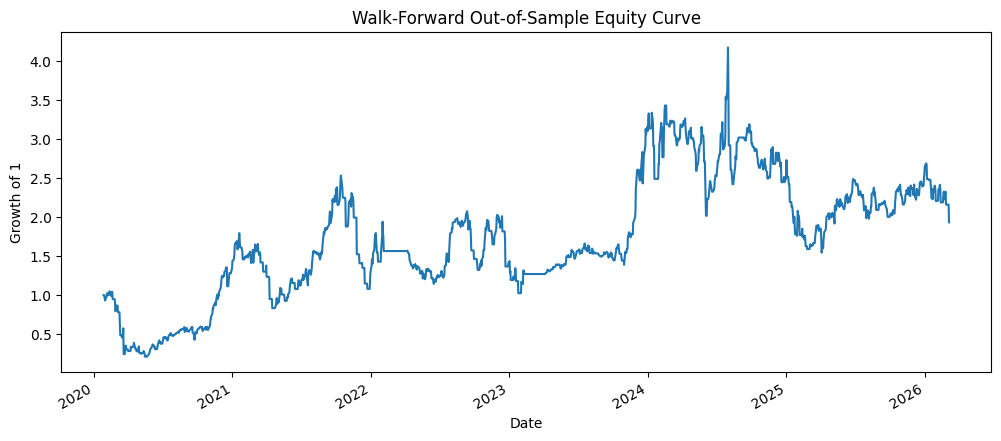

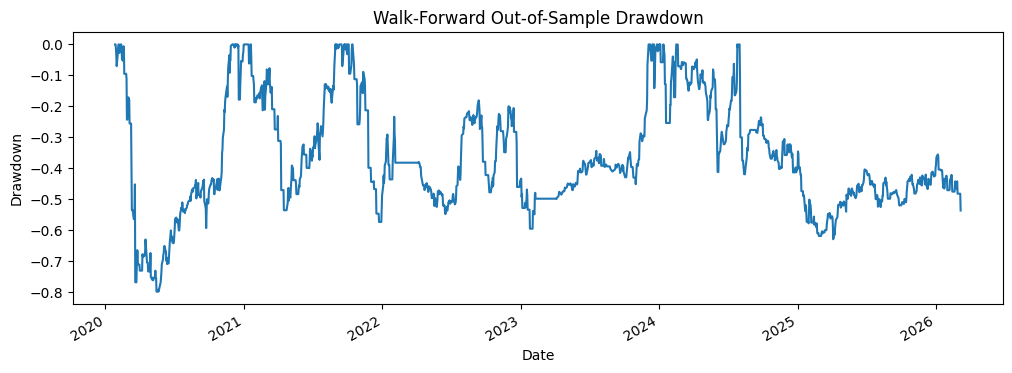

In [12]:
if not wf_returns.empty:
    wf_equity = (1 + wf_returns).cumprod()
    wf_equity.plot(figsize=(12, 5), title="Walk-Forward Out-of-Sample Equity Curve")
    plt.ylabel("Growth of 1")
    plt.show()

    wf_dd = wf_equity / wf_equity.cummax() - 1
    wf_dd.plot(figsize=(12, 4), title="Walk-Forward Out-of-Sample Drawdown")
    plt.ylabel("Drawdown")
    plt.show()
else:
    print("No walk-forward returns generated. Check data length and grid constraints.")


## 11. Stability checks

A useful alpha rule should not be fragile.

We check:

- Are chosen parameters stable across folds?
- Does performance depend on one exact threshold?
- Does the rule trade enough days to be meaningful?
- Are drawdowns actually lower out of sample?


In [13]:
if not wf_report.empty:
    for col in ["chosen_top_n", "chosen_min_signal", "chosen_rebalance_every", "chosen_max_holdings", "chosen_regime_filter", "chosen_stop_loss"]:
        print("\n", col)
        display(wf_report[col].value_counts(dropna=False).to_frame("fold_count"))

    display(wf_report[[c for c in wf_report.columns if c.startswith("test_")]].describe().T)
else:
    print("Walk-forward report is empty.")



 chosen_top_n


,fold_count
chosen_top_n,
10,6
5,6



 chosen_min_signal


,fold_count
chosen_min_signal,
0.4,6
0.0,3
0.3,3



 chosen_rebalance_every


...


 chosen_regime_filter


,fold_count
chosen_regime_filter,
not_high_vol,5
all,4
nifty_bull_or_sideways,1
bull_and_not_high_vol,1
nifty_bull_only,1



 chosen_stop_loss


,fold_count
chosen_stop_loss,
-0.04,7
-0.06,4
-0.08,1


,count,mean,min,25%,50%,75%,max,std
test_start,12,2022-11-13 06:00:00,2020-01-27 00:00:00,2021-06-19 18:00:00,2022-11-10 00:00:00,2024-04-08 12:00:00,2025-09-03 00:00:00,NaN
test_end,12,2023-05-16 16:00:00,2020-07-30 00:00:00,2021-12-20 00:00:00,2023-05-14 00:00:00,2024-10-12 06:00:00,2026-03-06 00:00:00,NaN
test_total_return,12.0,0.205222,-0.512616,-0.166666,0.036474,0.268675,1.992817,0.706384
test_ann_return,12.0,0.909955,-0.762457,-0.295036,0.075556,0.612458,7.956952,2.471093
test_ann_vol,12.0,0.652683,0.219923,0.457806,0.678011,0.729395,1.476198,0.314374
test_sharpe,12.0,1.553744,-1.456674,-0.479601,0.105698,1.903285,11.474795,3.578225
test_max_drawdown,12.0,-0.389159,-0.799733,-0.503176,-0.35088,-0.267447,-0.078765,0.197311
test_calmar,12.0,4.123203,-1.440793,-0.779642,0.151639,4.598048,28.590423,8.765102
test_hit_rate,12.0,0.439153,0.309524,0.375,0.436508,0.488095,0.666667,0.094957
test_avg_daily_return,12.0,0.001573,-0.004598,-0.000362,0.00148,0.002209,0.00971,0.003766


## 12. Latest optimized trade candidates

This final table translates the selected rule into candidate trade ideas.

These are **not automatic trades**. They are hypothesis-backed candidates:

- Signal: oriented Alpha#1 score
- Hypothesis: Alpha#1 works only under selected threshold/regime conditions
- Validation: grid + regime + walk-forward evidence
- Decision: human approval required


In [15]:
def latest_trade_candidates(alpha: pd.DataFrame, regimes: pd.DataFrame, params: StrategyParams) -> pd.DataFrame:
    latest_date = alpha.dropna(how="all").index[-1]
    regime_row = regimes.reindex(alpha.index).loc[latest_date]
    allowed = allowed_by_regime(regime_row, params.regime_filter)
    scores = alpha.loc[latest_date].dropna().sort_values(ascending=False)
    scores = scores[scores >= params.min_signal]
    selected = scores.head(min(params.top_n, params.max_holdings)) if allowed else pd.Series(dtype=float)
    return pd.DataFrame({
        "date": latest_date,
        "symbol": selected.index,
        "oriented_alpha001": selected.values,
        "raw_alpha001": raw_alpha001.reindex(index=[latest_date], columns=selected.index).iloc[0].values if len(selected) else [],
        "signal_orientation": ORIENTATION_LABEL,
        "regime_filter": params.regime_filter,
        "trend_regime": regime_row.get("trend_regime"),
        "vol_regime": regime_row.get("vol_regime"),
        "suggested_action": "candidate_long",
        "reason": f"passes Alpha#1 threshold {params.min_signal}, top_n {params.top_n}, max_holdings {params.max_holdings}, regime_allowed={allowed}",
    })

# Use best in-sample params for candidate generation, but compare with walk-forward stability before trusting.
candidates = latest_trade_candidates(oriented_alpha001, regimes, best_params)
display(candidates)
candidates.to_csv(ARTIFACT_DIR / "alpha001_latest_optimized_trade_candidates.csv", index=False)


,date,symbol,oriented_alpha001,raw_alpha001,signal_orientation,regime_filter,trend_regime,vol_regime,suggested_action,reason


## 13. Decision checklist

After running this notebook, answer these questions before promoting Alpha#1:

1. Did optimized Sharpe improve versus baseline?
2. Did max drawdown reduce versus baseline?
3. Did walk-forward OOS remain positive?
4. Are selected parameters reasonably stable?
5. Does the regime filter match the regime attribution?
6. Does the rule trade often enough?
7. Does performance survive realistic costs?
8. Are trade candidates diversified and liquid?

Suggested promotion standard for Alpha#1 v1:

```text
Draft → Testing only if:
- Walk-forward Sharpe > baseline Sharpe
- Walk-forward max drawdown improves by at least 20%
- Positive OOS return after costs
- At least 4 walk-forward folds
- No single stock dominates realized returns
- Regime explanation is economically plausible
```

If these checks fail, do not discard Alpha#1 immediately. Mark it as:

```text
alpha_001_nifty50: useful as weak filter / avoid signal / regime-specific signal
```

rather than a standalone trade generator.


## 14. Export summary

The notebook writes:

```text
research/artifacts/alpha001_nifty50_optimization/
├── alpha001_threshold_regime_grid_results.csv
├── alpha001_threshold_regime_leaderboard.csv
├── alpha001_optimized_regime_attribution.csv
├── alpha001_walk_forward_report.csv
├── alpha001_walk_forward_returns.csv
└── alpha001_latest_optimized_trade_candidates.csv
```

Recommended notebook path:

```text
research/notebooks/nifty50_alpha001_trade_optimization_guided.ipynb
```
